In [80]:
!pip install xgboost seaborn scikit-learn pandas numpy matplotlib

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les bibliothèques nécessaires

# ==========================
# 1. CHARGEMENT DES DONNÉES
# ==========================
df = pd.read_csv('job-automation-probability.csv')

# Copier le dataset pour éviter de modifier l'original
df = df.copy()

print("Données chargées")
print(f"Shape : {df.shape}")  # Affiche le nombre de lignes et colonnes

# ==========================
# 2. NETTOYAGE DES NOMS DE COLONNES
# ==========================

# Mettre les noms de colonnes en minuscules
# Supprimer les espaces inutiles
# Remplacer les espaces par des underscores
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# ==========================
# 3. SUPPRESSION DES COLONNES DOUBLONS
# ==========================

# Garder seulement les colonnes uniques
df = df.loc[:, ~df.columns.duplicated()]

# ==========================
# 4. VÉRIFICATION RAPIDE DU DATASET
# ==========================

# Afficher les premières lignes
display(df.head())

# Informations générales sur le dataset
print("\nInfos dataset :")
df.info()

# Statistiques descriptives des colonnes numériques
print("\nStatistiques :")
display(df.describe())

# Vérifier les valeurs manquantes dans chaque colonne
print("\nValeurs manquantes :")
print(df.isnull().sum())

Données chargées
Shape : (702, 13)


,__-_rank,__-_code,prob,average_annual_wage,education,occupation,short_occupation,len,probability,numbemployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.950,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,0.950,74600,32890.0,74600,34920.0
1,517,51-9012,0.880,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,0.880,47160,38360.0,47160,41450.0
2,484,41-4012,0.850,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,0.850,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.029,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,0.029,202760,57270.0,202760,59800.0
4,620,51-4072,0.950,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,0.950,145560,30480.0,145560,32660.0



Infos dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   __-_rank             702 non-null    int64  
 1   __-_code             702 non-null    object 
 2   prob                 702 non-null    float64
 3   average_annual_wage  702 non-null    float64
 4   education            702 non-null    object 
 5   occupation           702 non-null    object 
 6   short_occupation     702 non-null    object 
 7   len                  702 non-null    int64  
 8   probability          702 non-null    float64
 9   numbemployed         702 non-null    int64  
 10  median_ann_wage      702 non-null    float64
 11  employed_may2016     702 non-null    object 
 12  average_ann_wage     702 non-null    float64
dtypes: float64(5), int64(3), object(5)
memory usage: 71.4+ KB

Statistiques :


,__-_rank,prob,average_annual_wage,len,probability,numbemployed,median_ann_wage,average_ann_wage
count,702.000000,702.000000,702.000000,702.000000,702.000000,7.020000e+02,702.000000,702.000000
mean,351.500000,0.535550,55645.277920,33.478632,0.535550,1.868357e+05,51345.467521,55645.277920
std,202.794231,0.368149,28985.949485,17.485644,0.368149,4.231402e+05,26912.978600,28985.949485
min,1.000000,0.002800,20460.000000,6.000000,0.002800,3.700000e+02,19290.000000,20460.000000
25%,176.250000,0.110000,35757.500000,19.000000,0.110000,1.730750e+04,33355.000000,35757.500000
50%,351.500000,0.640000,47915.000000,31.000000,0.640000,4.899000e+04,44370.000000,47915.000000
75%,526.750000,0.890000,66477.500000,44.000000,0.890000,1.517025e+05,61652.500000,66477.500000
max,702.000000,0.990000,232870.000000,92.000000,0.990000,4.528550e+06,232870.000000,232870.000000



Valeurs manquantes :
__-_rank               0
__-_code               0
prob                   0
average_annual_wage    0
education              0
occupation             0
short_occupation       0
len                    0
probability            0
numbemployed           0
median_ann_wage        0
employed_may2016       0
average_ann_wage       0
dtype: int64


In [97]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# ==========================
# 1. COPIE DU DATASET
# ==========================

# Créer une copie pour éviter de modifier les données originales
df = df.copy()

# ==========================
# 2. NORMALISATION DES NOMS DE COLONNES
# ==========================

# Mettre les noms en minuscules
# Supprimer les espaces
# Remplacer les espaces par des underscores
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

print("Colonnes initiales :", df.columns.tolist())

# ==========================
# 3. SUPPRESSION DES COLONNES INUTILES
# ==========================

# Liste des colonnes à supprimer si elles existent
drop_cols = ['probability', 'len']

# Supprimer uniquement celles qui existent dans le dataset
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# ==========================
# 4. SUPPRESSION DES DOUBLONS
# ==========================

# Garder uniquement les colonnes uniques
df = df.loc[:, ~df.columns.duplicated()]

# ==========================
# 5. NETTOYAGE DE LA TARGET
# ==========================

# Supprimer les lignes où la cible 'prob' est manquante
df = df.dropna(subset=['prob'])

# ==========================
# 6. CONVERSION DES VARIABLES NUMÉRIQUES
# ==========================

# Sélectionner les colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Convertir en numérique et remplacer les valeurs manquantes par la médiane
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# ==========================
# 7. NETTOYAGE DES VARIABLES CATÉGORIELLES
# ==========================

# Sélectionner les colonnes texte
categorical_cols = df.select_dtypes(include=['object']).columns

# Remplacer les valeurs manquantes par "Unknown"
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

# ==========================
# 8. SUPPRESSION DES OUTLIERS
# ==========================

# Recalculer les colonnes numériques après nettoyage
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Calculer les z-scores pour détecter les valeurs extrêmes
z_scores = np.abs(zscore(df[numeric_cols], nan_policy='omit'))

# Garder uniquement les lignes sans valeurs extrêmes
df = df[(z_scores < 3).all(axis=1)]

# ==========================
# 9. RÉSULTAT FINAL
# ==========================

print(f"\nAprès nettoyage : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Afficher les premières lignes
df.head()

Colonnes initiales : ['__-_rank', '__-_code', 'prob', 'average_annual_wage', 'education', 'occupation', 'short_occupation', 'len', 'probability', 'numbemployed', 'median_ann_wage', 'employed_may2016', 'average_ann_wage']

Après nettoyage : 674 lignes, 11 colonnes


,__-_rank,__-_code,prob,average_annual_wage,education,occupation,short_occupation,numbemployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.950,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",74600,32890.0,74600,34920.0
1,517,51-9012,0.880,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",47160,38360.0,47160,41450.0
2,484,41-4012,0.850,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",1404050,57140.0,1404050,68410.0
3,105,53-1031,0.029,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,202760,57270.0,202760,59800.0
4,620,51-4072,0.950,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",145560,30480.0,145560,32660.0


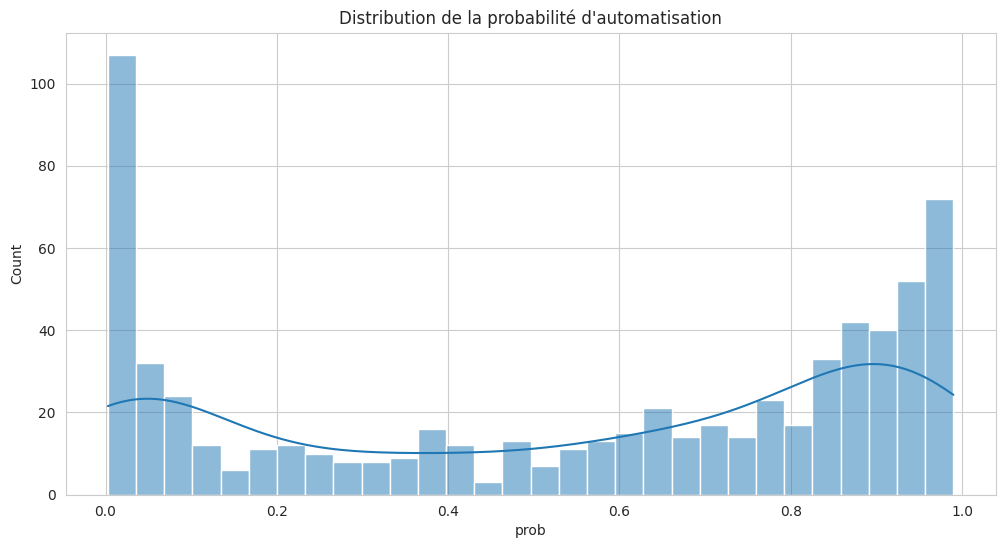

Skewness de 'prob' : -0.3017751391498656


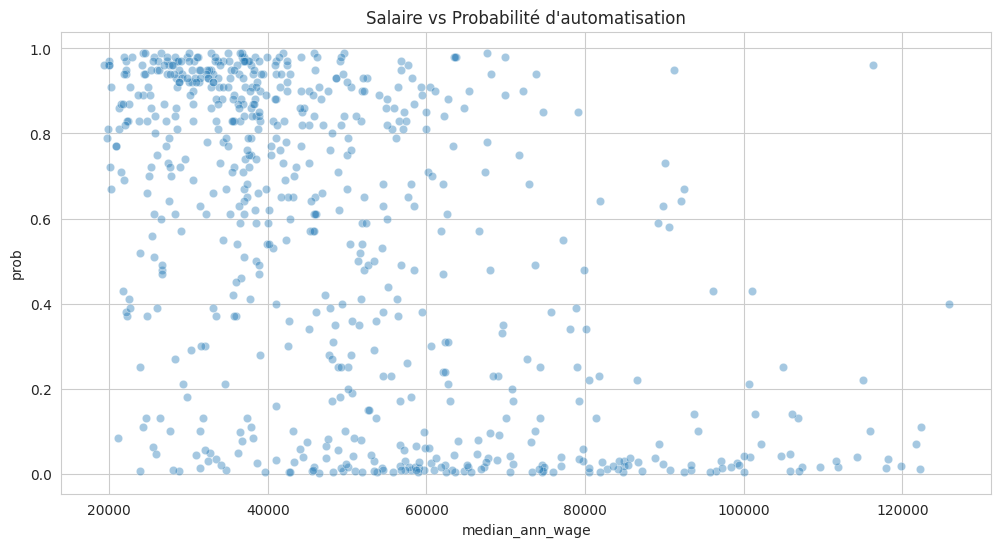

Corrélation salaire / prob : -0.526


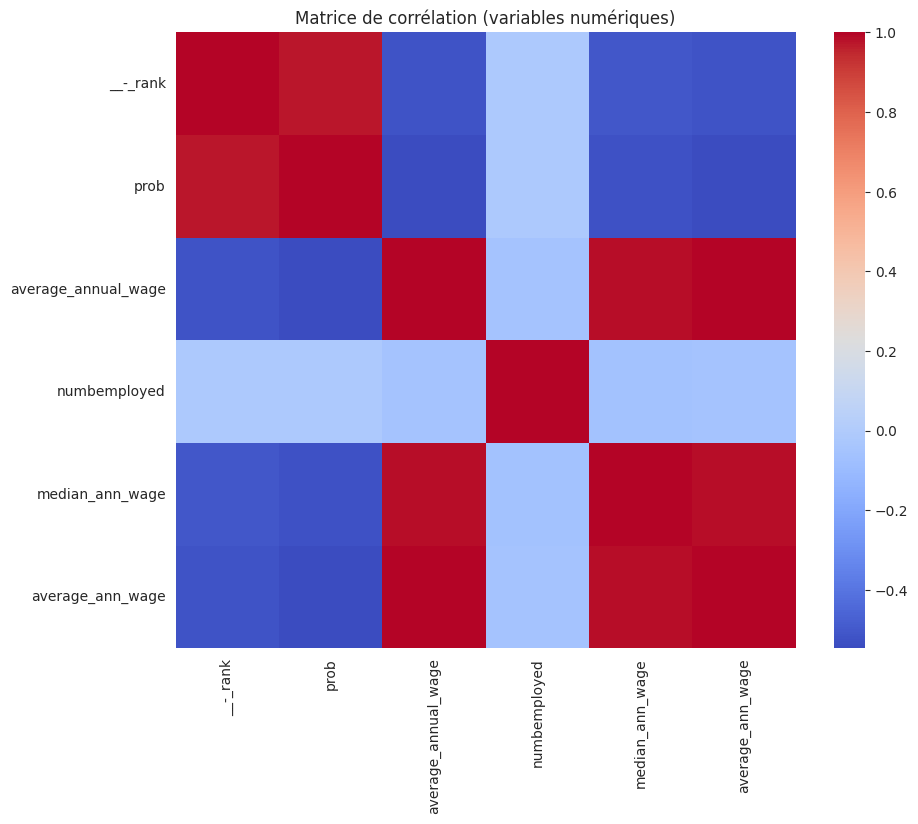

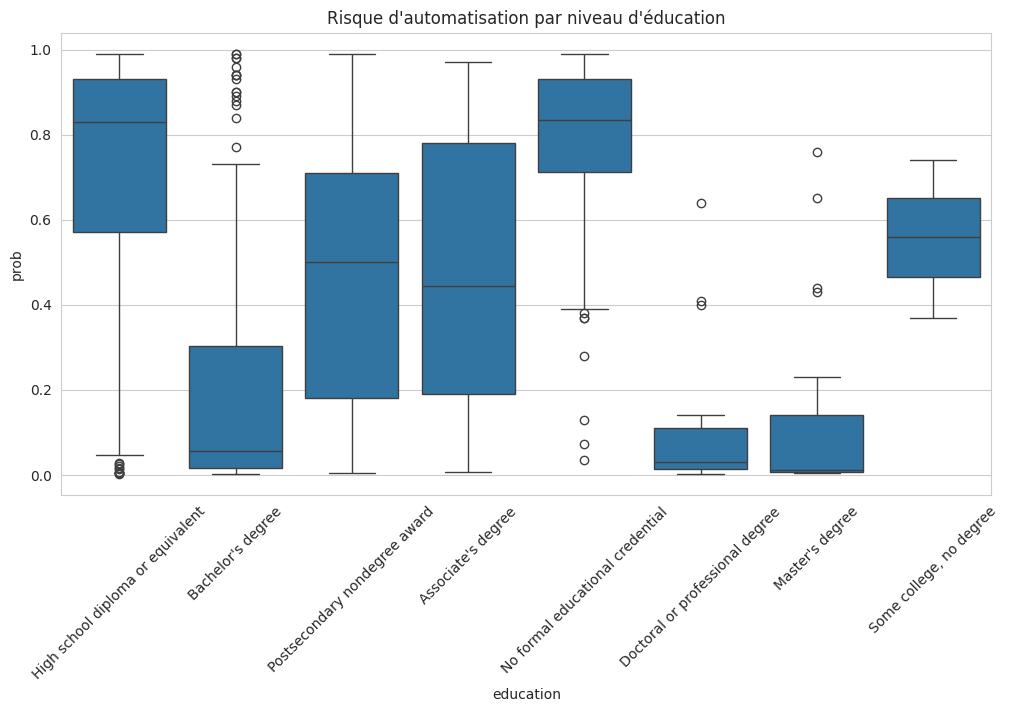


Impact moyen par éducation :
education
Master's degree                      0.119852
Doctoral or professional degree      0.119906
Bachelor's degree                    0.223917
Associate's degree                   0.470645
Postsecondary nondegree award        0.473161
Some college, no degree              0.556667
High school diploma or equivalent    0.706331
No formal educational credential     0.778100
Name: prob, dtype: float64

Métiers les plus automatisables :
                                                   occupation  prob
Photographic Process Workers and Processing Machine Operators  0.99
                   Title Examiners, Abstractors and Searchers  0.99
                                     Cargo and Freight Agents  0.99
                                     Mathematical Technicians  0.99
                                       Insurance Underwriters  0.99
                                          Library Technicians  0.99
                                          New Accounts

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================
# STYLE DES GRAPHIQUES
# ==========================

# Définir le style des graphiques
sns.set_style("whitegrid")

# Définir la taille par défaut des figures
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================
# 0. VÉRIFICATION DE LA TARGET
# ==========================

# Vérifier si la colonne cible existe
if 'prob' not in df.columns:
    raise ValueError("colonne prob manquante")

# ==========================
# 1. DISTRIBUTION DE LA TARGET
# ==========================

# Afficher la distribution de la variable cible
plt.figure()
sns.histplot(df['prob'], bins=30, kde=True)
plt.title("Distribution de la probabilité d'automatisation")
plt.show()

# Calculer l'asymétrie (skewness)
print("Skewness de 'prob' :", df['prob'].skew())

# ==========================
# 2. SALAIRE VS TARGET
# ==========================

# Choisir la colonne salaire disponible
wage_col = 'median_ann_wage' if 'median_ann_wage' in df.columns else 'average_ann_wage'

# Vérifier si la colonne existe
if wage_col in df.columns:
    plt.figure()

    # Nuage de points salaire vs probabilité
    sns.scatterplot(data=df, x=wage_col, y='prob', alpha=0.4)
    plt.title("Salaire vs Probabilité d'automatisation")
    plt.show()

    # Calcul de la corrélation
    corr = df['prob'].corr(df[wage_col])
    print(f"Corrélation salaire / prob : {corr:.3f}")
else:
    print("Colonne salaire introuvable")

# ==========================
# 3. MATRICE DE CORRÉLATION
# ==========================

# Sélectionner uniquement les variables numériques
num_df = df.select_dtypes(include=[np.number])

# Vérifier qu'il y a assez de variables
if num_df.shape[1] > 1:
    plt.figure(figsize=(10, 8))

    # Heatmap des corrélations
    sns.heatmap(num_df.corr(), cmap='coolwarm', annot=False)
    plt.title("Matrice de corrélation (variables numériques)")
    plt.show()
else:
    print("Pas assez de variables numériques pour la corrélation")

# ==========================
# 4. IMPACT DE L'ÉDUCATION
# ==========================

# Vérifier si la colonne education existe
if 'education' in df.columns:

    # Garder les 8 niveaux d'éducation les plus fréquents
    top_edu = df['education'].value_counts().index[:8]

    plt.figure()

    # Boxplot de la probabilité selon l'éducation
    sns.boxplot(data=df[df['education'].isin(top_edu)], x='education', y='prob')
    plt.xticks(rotation=45)
    plt.title("Risque d'automatisation par niveau d'éducation")
    plt.show()

    # Moyenne de la probabilité par niveau d'éducation
    edu_mean = df.groupby('education')['prob'].mean().sort_values()

    print("\nImpact moyen par éducation :")
    print(edu_mean)
else:
    print("colonne education absente")

# ==========================
# 5. MÉTIERS LES PLUS ET MOINS AUTOMATISABLES
# ==========================

# Vérifier si la colonne occupation existe
if 'occupation' in df.columns:

    # Top 10 des métiers les plus automatisables
    top_auto = df.nlargest(10, 'prob')[['occupation', 'prob']]

    # Top 10 des métiers les moins automatisables
    bottom_auto = df.nsmallest(10, 'prob')[['occupation', 'prob']]

    print("\nMétiers les plus automatisables :")
    print(top_auto.to_string(index=False))

    print("\nMétiers les moins automatisables :")
    print(bottom_auto.to_string(index=False))
else:
    print("colonne occupation absente")

In [99]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Créer une copie du dataset pour éviter les modifications directes
df = df.copy()

# ==========================
# NETTOYAGE DE LA COLONNE OCCUPATION
# ==========================

# Créer une version propre de la colonne occupation
df['occupation_clean'] = df['occupation'].fillna('').astype(str).str.lower()

# Fonction pour regrouper les métiers en catégories
def extract_keywords(text):
    text = str(text).lower()

    if ('engineer' in text) or ('technician' in text):
        return 'technical'
    elif ('manager' in text) or ('supervisor' in text):
        return 'management'
    elif ('sales' in text) or ('retail' in text):
        return 'sales'
    elif ('teacher' in text) or ('education' in text):
        return 'education'
    elif ('health' in text) or ('medical' in text) or ('nurse' in text):
        return 'healthcare'
    elif ('construction' in text) or ('mining' in text) or ('extraction' in text):
        return 'construction'
    elif ('food' in text) or ('cook' in text) or ('restaurant' in text):
        return 'food_service'
    else:
        return 'other'

# Appliquer la classification des métiers
df['industry_category'] = df['occupation_clean'].apply(extract_keywords)

# ==========================
# ENCODAGE DE LA VARIABLE CATEGORIELLE
# ==========================

# Calcul de la moyenne globale de la cible
global_mean = df['prob'].mean()

# Calcul de la moyenne de probabilité par catégorie
industry_mean = df.groupby('industry_category')['prob'].mean()

# Remplacer chaque catégorie par sa moyenne de probabilité
df['industry_encoded'] = df['industry_category'].map(industry_mean).fillna(global_mean)

# ==========================
# NETTOYAGE DES VARIABLES NUMÉRIQUES
# ==========================

# Choisir la colonne salaire disponible
wage_col = 'median_ann_wage' if 'median_ann_wage' in df.columns else 'average_ann_wage'

# Conversion en numérique
df[wage_col] = pd.to_numeric(df[wage_col], errors='coerce')
df['numbemployed'] = pd.to_numeric(df['numbemployed'], errors='coerce')

# Remplacer les valeurs manquantes par la médiane
df[wage_col] = df[wage_col].fillna(df[wage_col].median())
df['numbemployed'] = df['numbemployed'].fillna(df['numbemployed'].median())

# ==========================
# STANDARDISATION DES VARIABLES
# ==========================

# Initialiser le scaler
scaler = StandardScaler()

# Normaliser le salaire et le nombre d'employés
df[['wage_normalized', 'employed_normalized']] = scaler.fit_transform(
    df[[wage_col, 'numbemployed']]
)

In [100]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor

# Créer une copie du dataset pour éviter de modifier l'original
df = df.copy()

# ==========================
# NETTOYAGE DES VARIABLES NUMÉRIQUES
# ==========================

# Liste des colonnes numériques à nettoyer
num_cols = ['numbemployed', 'median_ann_wage', 'employed_may2016']

# Conversion en numérique et remplissage des valeurs manquantes
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# ==========================
# PRÉPARATION DE LA VARIABLE CIBLE
# ==========================

# Supprimer les lignes où la cible est manquante
df = df.dropna(subset=['prob'])

# ==========================
# SÉPARATION TRAIN / TEST
# ==========================

# Diviser les données en ensemble d'entraînement et de test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# ==========================
# SÉLECTION DES VARIABLES EXPLICATIVES
# ==========================

# Choisir les variables utilisées pour le modèle
features = [
    'education',
    'industry_category',
    'numbemployed',
    'median_ann_wage',
    'employed_may2016'
]

X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df['prob']
y_test = test_df['prob']

# ==========================
# IDENTIFICATION DES VARIABLES CATÉGORIELLES
# ==========================

# CatBoost doit connaître les colonnes catégorielles
cat_features = []

for i, col in enumerate(features):
    if X_train[col].dtype == 'object':
        cat_features.append(i)

# ==========================
# ENTRAÎNEMENT DU MODÈLE CATBOOST
# ==========================

# Définition du modèle
model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

# Entraînement du modèle
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# ==========================
# PRÉDICTIONS
# ==========================

# Prédire les valeurs sur le test set
y_pred = model.predict(X_test)

# Limiter les prédictions entre 0 et 1
y_pred = np.clip(y_pred, 0, 1)

# ==========================
# ÉVALUATION DU MODÈLE
# ==========================

# Calcul des métriques de performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nRÉSULTATS DU MODÈLE CATBOOST")
print("RMSE :", rmse)
print("R² :", r2)

# ==========================
# IMPORTANCE DES VARIABLES
# ==========================

# Calcul de l'importance des features
importances = pd.Series(
    model.get_feature_importance(),
    index=features
).sort_values(ascending=False)

print("\nIMPORTANCE DES VARIABLES :")
print(importances)

0:	learn: 0.3543535	test: 0.3741369	best: 0.3741369 (0)	total: 8.94ms	remaining: 7.15s
200:	learn: 0.2179022	test: 0.2825447	best: 0.2822135 (192)	total: 981ms	remaining: 2.92s
400:	learn: 0.1854762	test: 0.2841600	best: 0.2822135 (192)	total: 1.74s	remaining: 1.73s
600:	learn: 0.1606992	test: 0.2848287	best: 0.2822135 (192)	total: 2.8s	remaining: 928ms
799:	learn: 0.1419891	test: 0.2855118	best: 0.2822135 (192)	total: 3.58s	remaining: 0us

bestTest = 0.2822134592
bestIteration = 192

Shrink model to first 193 iterations.

RÉSULTATS DU MODÈLE CATBOOST
RMSE : 0.2822134595489244
R² : 0.44967788345393145

IMPORTANCE DES VARIABLES :
education            37.809869
median_ann_wage      24.644696
industry_category    16.917802
employed_may2016     10.727762
numbemployed          9.899871
dtype: float64


In [101]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

# ==========================
# 0. CHARGEMENT DES DONNÉES
# ==========================

# Charger le dataset et créer une copie
df = pd.read_csv("job-automation-probability.csv").copy()

# ==========================
# 1. NETTOYAGE DES VARIABLES NUMÉRIQUES
# ==========================

# Liste des colonnes numériques à nettoyer
for col in ['numbemployed', 'median_ann_wage', 'employed_may2016']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Supprimer les lignes où la cible est manquante
df = df.dropna(subset=['prob'])

# ==========================
# 2. ENCODAGE DES VARIABLES CATÉGORIELLES
# ==========================

# Moyenne globale de la cible
global_mean = df['prob'].mean()

# Encodage de la colonne education
edu_map = df.groupby('education')['prob'].mean()
df['education_encoded'] = df['education'].map(edu_map).fillna(global_mean)

# Encodage de industry_category si elle existe
if 'industry_category' in df.columns:
    ind_map = df.groupby('industry_category')['prob'].mean()
    df['industry_encoded'] = df['industry_category'].map(ind_map).fillna(global_mean)
else:
    df['industry_encoded'] = global_mean

# ==========================
# 3. SÉLECTION DES VARIABLES
# ==========================

# Liste des variables utilisées pour le modèle
features = [
    'education_encoded',
    'industry_encoded',
    'numbemployed',
    'median_ann_wage',
    'employed_may2016'
]

# Garder uniquement les colonnes disponibles
features = [c for c in features if c in df.columns]

# Séparer X et y
X = df[features].copy()
y = df['prob']

# Forcer la conversion en numérique pour éviter les erreurs
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# ==========================
# 4. TRAIN / TEST SPLIT
# ==========================

# Séparer les données en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================
# 5. STANDARDISATION
# ==========================

# Normalisation des données (utile pour XGBoost)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# 6. RANDOM FOREST
# ==========================

# Création du modèle Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Entraînement du modèle
rf.fit(X_train, y_train)

# Prédictions Random Forest
pred_rf = rf.predict(X_test)

# ==========================
# 7. XGBOOST
# ==========================

# Création du modèle XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Entraînement sur données normalisées
xgb.fit(X_train_scaled, y_train)

# Prédictions XGBoost
pred_xgb = xgb.predict(X_test_scaled)

# ==========================
# 8. ÉVALUATION DES MODÈLES
# ==========================

# Fonction d'évaluation des performances
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n=== {name} ===")
    print("RMSE:", rmse)
    print("R2:", r2)

# Résultats des deux modèles
evaluate("Random Forest", y_test, pred_rf)
evaluate("XGBoost", y_test, pred_xgb)


=== Random Forest ===
RMSE: 0.2887663121173815
R2: 0.3681442200983084

=== XGBoost ===
RMSE: 0.32450710947569805
R2: 0.20205429463547198
